### 03 - Traditional Machine Learning Baseline: HOG + SVM

This notebook develops a traditional machine learning baseline for the traffic image classification project.

The baseline consists of:

1. A majority-class dummy classifier.
2. Histogram of Oriented Gradients (HOG) feature extraction.
3. A Support Vector Machine (SVM) classifier.
4. Performance evaluation using accuracy, precision, recall, macro F1-score and confusion matrices.

The purpose of this notebook is to provide a comparison between:

- a simple non-learning baseline;
- traditional machine learning using manually engineered features;
- later convolutional neural network models that learn image features automatically.

The main workflow of this notebook:

1. Load the processed train, validation and test datasets.
2. Inspect the dataset structure.
3. Resize and normalise the images.
4. Extract HOG features.
5. Train a majority-class baseline.
6. Train a linear SVM classifier.
7. Evaluate both models.
8. Save the trained model, metrics and figures.

In [1]:
import os
import json
import time
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from PIL import Image, UnidentifiedImageError
from IPython.display import display
from skimage.feature import hog

from sklearn.dummy import DummyClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

/Users/liuyuhan/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Libraries imported successfully.


In [2]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

print(f"Random seed set to {RANDOM_STATE}.")

Random seed set to 42.


##### 1. Project Paths and Configuration

The notebook is stored in the `notebooks` directory. The train, validation and test splits were created during preprocessing and saved as CSV files inside: `data/processed/`

In [3]:
CURRENT_DIR = Path.cwd()

# If the notebook is running from the notebooks folder, the parent directory is the project root.
if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

TRAIN_CSV = PROCESSED_DATA_DIR / "train_split.csv"
VAL_CSV = PROCESSED_DATA_DIR / "validation_split.csv"
TEST_CSV = PROCESSED_DATA_DIR / "test_split.csv"

MODEL_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DATA_DIR)
print("Processed data directory:", PROCESSED_DATA_DIR)
print()
print("Training CSV:", TRAIN_CSV)
print("Validation CSV:", VAL_CSV)
print("Test CSV:", TEST_CSV)
print()
print("Model output directory:", MODEL_DIR)
print("Results output directory:", RESULTS_DIR)

Project root: /Users/liuyuhan/Desktop/traffic_recognition
Raw data directory: /Users/liuyuhan/Desktop/traffic_recognition/data/raw
Processed data directory: /Users/liuyuhan/Desktop/traffic_recognition/data/processed

Training CSV: /Users/liuyuhan/Desktop/traffic_recognition/data/processed/train_split.csv
Validation CSV: /Users/liuyuhan/Desktop/traffic_recognition/data/processed/validation_split.csv
Test CSV: /Users/liuyuhan/Desktop/traffic_recognition/data/processed/test_split.csv

Model output directory: /Users/liuyuhan/Desktop/traffic_recognition/models
Results output directory: /Users/liuyuhan/Desktop/traffic_recognition/results


In [4]:
# Check whether the required CSV split files exist
required_files = {
    "training CSV": TRAIN_CSV,
    "validation CSV": VAL_CSV,
    "test CSV": TEST_CSV
}

missing_files = []

for file_name, file_path in required_files.items():
    if file_path.exists():
        print(f"[OK] {file_name.capitalize()} found: {file_path}")
    else:
        print(f"[MISSING] {file_name.capitalize()} not found: {file_path}")
        missing_files.append(file_name)

if missing_files:
    raise FileNotFoundError(
        "The following required files were not found: "
        + ", ".join(missing_files)
        + ". Check the paths defined in the previous cell."
    )

print("\nAll required dataset split files were found.")

[OK] Training csv found: /Users/liuyuhan/Desktop/traffic_recognition/data/processed/train_split.csv
[OK] Validation csv found: /Users/liuyuhan/Desktop/traffic_recognition/data/processed/validation_split.csv
[OK] Test csv found: /Users/liuyuhan/Desktop/traffic_recognition/data/processed/test_split.csv

All required dataset split files were found.


##### 2. Load the Dataset Split CSV Files

Each CSV should contain at least:

- a column containing the image path;
- a column containing the class label.

The exact column names are detected automatically in the following cells.

In [5]:
# Load the dataset split CSV files
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("CSV files loaded successfully.\n")

print("Training dataframe shape:", train_df.shape)
print("Validation dataframe shape:", val_df.shape)
print("Test dataframe shape:", test_df.shape)

print("\nTraining dataframe columns:")
print(train_df.columns.tolist())

print("\nFirst five training rows:")
display(train_df.head())

CSV files loaded successfully.

Training dataframe shape: (31367, 8)
Validation dataframe shape: (7842, 8)
Test dataframe shape: (12630, 8)

Training dataframe columns:
['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']

First five training rows:


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,56,56,5,5,51,51,12,Train/12/00012_00031_00018.png
1,27,28,6,5,22,23,5,Train/5/00005_00031_00001.png
2,92,94,8,9,84,86,12,Train/12/00012_00069_00028.png
3,60,53,6,5,54,48,13,Train/13/00013_00052_00022.png
4,64,58,6,5,59,53,18,Train/18/00018_00017_00024.png


In [6]:
# Detect path and label columns
PATH_COLUMN = "Path"
LABEL_COLUMN = "ClassId"

required_columns = [
    PATH_COLUMN,
    LABEL_COLUMN
]

missing_columns = [
    column
    for column in required_columns
    if column not in train_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}\n"
        f"Available columns: {train_df.columns.tolist()}"
    )

print("Image path column:", PATH_COLUMN)
print("Class label column:", LABEL_COLUMN)

Image path column: Path
Class label column: ClassId


In [7]:
# Check CSV column consistency
dataset_frames = {
    "training": train_df,
    "validation": val_df,
    "test": test_df
}

for split_name, dataframe in dataset_frames.items():
    missing_columns = [
        column
        for column in [PATH_COLUMN, LABEL_COLUMN]
        if column not in dataframe.columns
    ]

    if missing_columns:
        raise ValueError(
            f"The {split_name} CSV is missing required columns: "
            f"{missing_columns}"
        )

print("All dataset splits contain the required path and label columns.")

All dataset splits contain the required path and label columns.


##### 3. Resolve Image Paths

The paths stored in the CSV files may be:

- absolute paths;
- relative to the project directory;
- relative to the `data` directory;
- relative to the `data/raw` directory.

The following function tests several possible locations and returns the first valid image path.

In [8]:
DATASET_ROOT = RAW_DATA_DIR / "archive"

def resolve_image_path(path_value):
    """
    Resolve an image path stored in the split CSV files.

    CSV paths such as:
        Train/0/00000_00000_00000.png

    are resolved relative to:
        data/raw/archive/
    """
    stored_path = Path(str(path_value).strip()).expanduser()

    candidates = [
        # Absolute path, if one is already stored
        stored_path,

        # Most likely location for this project
        DATASET_ROOT / stored_path,

        # Other fallback locations
        RAW_DATA_DIR / stored_path,
        DATA_DIR / stored_path,
        PROJECT_ROOT / stored_path,
        PROCESSED_DATA_DIR / stored_path
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    # Return the expected dataset path for useful error reporting
    return (DATASET_ROOT / stored_path).resolve()


first_stored_path = train_df.iloc[0][PATH_COLUMN]
first_resolved_path = resolve_image_path(first_stored_path)

print("Dataset root:")
print(DATASET_ROOT)

print("\nPath stored in CSV:")
print(first_stored_path)

print("\nResolved image path:")
print(first_resolved_path)

print("\nFile exists:")
print(first_resolved_path.exists())

Dataset root:
/Users/liuyuhan/Desktop/traffic_recognition/data/raw/archive

Path stored in CSV:
Train/12/00012_00031_00018.png

Resolved image path:
/Users/liuyuhan/Desktop/traffic_recognition/data/raw/archive/Train/12/00012_00031_00018.png

File exists:
True


In [9]:
def check_dataframe_paths(dataframe, split_name):
    """
    Check how many image paths in a dataset split are valid.

    Returns
    -------
    pandas.Series
        Boolean mask indicating valid paths.
    """
    resolved_paths = dataframe[PATH_COLUMN].apply(resolve_image_path)
    valid_mask = resolved_paths.apply(lambda path: path.exists())

    valid_count = int(valid_mask.sum())
    invalid_count = int((~valid_mask).sum())

    print(f"{split_name} set:")
    print(f"  Total rows: {len(dataframe)}")
    print(f"  Valid image paths: {valid_count}")
    print(f"  Invalid image paths: {invalid_count}")

    if invalid_count > 0:
        print("\n  Example invalid stored paths:")

        invalid_examples = dataframe.loc[
            ~valid_mask,
            PATH_COLUMN
        ].head(10)

        for invalid_path in invalid_examples:
            print("   ", invalid_path)

    return valid_mask


train_valid_mask = check_dataframe_paths(
    train_df,
    "Training"
)

print()

val_valid_mask = check_dataframe_paths(
    val_df,
    "Validation"
)

print()

test_valid_mask = check_dataframe_paths(
    test_df,
    "Test"
)

Training set:
  Total rows: 31367
  Valid image paths: 31367
  Invalid image paths: 0

Validation set:
  Total rows: 7842
  Valid image paths: 7842
  Invalid image paths: 0

Test set:
  Total rows: 12630
  Valid image paths: 12630
  Invalid image paths: 0


In [10]:
# Stop the notebook if invalid image paths were found.
total_invalid_paths = (
    int((~train_valid_mask).sum())
    + int((~val_valid_mask).sum())
    + int((~test_valid_mask).sum())
)

if total_invalid_paths > 0:
    raise FileNotFoundError(
        f"{total_invalid_paths} image paths could not be resolved. "
        "Fix the paths before continuing."
    )

print("All image paths are valid.")

All image paths are valid.


##### 4. Class Labels and Mappings

Class labels are converted into integer values because scikit-learn classifiers operate using numerical targets.

The same class-to-index mapping is used for the training, validation and test datasets.

In [11]:
# Normalise label values

# Store labels as strings so that the three splits use one consistent representation
train_df[LABEL_COLUMN] = train_df[LABEL_COLUMN].astype(str)
val_df[LABEL_COLUMN] = val_df[LABEL_COLUMN].astype(str)
test_df[LABEL_COLUMN] = test_df[LABEL_COLUMN].astype(str)


def natural_class_sort(class_values):
    """
    Sort numerical labels numerically where possible.

    Examples
    --------
    Normal string sorting:
    0, 1, 10, 11, 2

    Natural numerical sorting:
    0, 1, 2, 10, 11
    """
    try:
        return sorted(
            class_values,
            key=lambda value: int(value)
        )
    except ValueError:
        return sorted(class_values)


train_class_names = natural_class_sort(
    train_df[LABEL_COLUMN].unique().tolist()
)

val_class_names = natural_class_sort(
    val_df[LABEL_COLUMN].unique().tolist()
)

test_class_names = natural_class_sort(
    test_df[LABEL_COLUMN].unique().tolist()
)

print("Number of training classes:", len(train_class_names))
print("Number of validation classes:", len(val_class_names))
print("Number of test classes:", len(test_class_names))

print("\nFirst ten training classes:")
print(train_class_names[:10])

Number of training classes: 43
Number of validation classes: 43
Number of test classes: 43

First ten training classes:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [12]:
# Check class consistency
train_class_set = set(train_class_names)
val_class_set = set(val_class_names)
test_class_set = set(test_class_names)

if train_class_set != val_class_set:
    print(
        "Classes missing from validation:",
        train_class_set - val_class_set
    )

    print(
        "Unexpected validation classes:",
        val_class_set - train_class_set
    )

    raise ValueError(
        "Training and validation classes do not match."
    )

if train_class_set != test_class_set:
    print(
        "Classes missing from test:",
        train_class_set - test_class_set
    )

    print(
        "Unexpected test classes:",
        test_class_set - train_class_set
    )

    raise ValueError(
        "Training and test classes do not match."
    )

CLASS_NAMES = train_class_names
NUM_CLASSES = len(CLASS_NAMES)

CLASS_TO_INDEX = {
    class_name: class_index
    for class_index, class_name in enumerate(CLASS_NAMES)
}

INDEX_TO_CLASS = {
    class_index: class_name
    for class_name, class_index in CLASS_TO_INDEX.items()
}

print("Classes are consistent across all dataset splits.")
print("Total number of classes:", NUM_CLASSES)

Classes are consistent across all dataset splits.
Total number of classes: 43


In [13]:
# Display and save the class mapping
class_mapping_df = pd.DataFrame({
    "class_index": list(range(NUM_CLASSES)),
    "class_name": [
        INDEX_TO_CLASS[index]
        for index in range(NUM_CLASSES)
    ]
})

class_mapping_path = (
    RESULTS_DIR / "hog_svm_class_mapping.csv"
)

class_mapping_df.to_csv(
    class_mapping_path,
    index=False
)

display(class_mapping_df)

print("\nClass mapping saved to:")
print(class_mapping_path)

,class_index,class_name
0,0,0
1,1,1
2,2,2
3,3,3
4,4,4
5,5,5
6,6,6
7,7,7
8,8,8
9,9,9



Class mapping saved to:
/Users/liuyuhan/Desktop/traffic_recognition/results/hog_svm_class_mapping.csv


##### 5. Dataset Distribution

The number of samples in each class is calculated directly from the CSV files.

Class imbalance may affect accuracy and class-level performance. The SVM model therefore uses balanced class weights.

In [14]:
# Class distribution
train_counts = train_df[LABEL_COLUMN].value_counts()
val_counts = val_df[LABEL_COLUMN].value_counts()
test_counts = test_df[LABEL_COLUMN].value_counts()

dataset_counts_df = pd.DataFrame({
    "class_name": CLASS_NAMES,
    "train_count": [
        int(train_counts.get(class_name, 0))
        for class_name in CLASS_NAMES
    ],
    "validation_count": [
        int(val_counts.get(class_name, 0))
        for class_name in CLASS_NAMES
    ],
    "test_count": [
        int(test_counts.get(class_name, 0))
        for class_name in CLASS_NAMES
    ]
})

dataset_counts_df["total_count"] = (
    dataset_counts_df["train_count"]
    + dataset_counts_df["validation_count"]
    + dataset_counts_df["test_count"]
)

print("Dataset sample counts:")
print("Training samples:", dataset_counts_df["train_count"].sum())
print(
    "Validation samples:",
    dataset_counts_df["validation_count"].sum()
)
print("Test samples:", dataset_counts_df["test_count"].sum())
print("Total samples:", dataset_counts_df["total_count"].sum())

display(dataset_counts_df)

Dataset sample counts:
Training samples: 31367
Validation samples: 7842
Test samples: 12630
Total samples: 51839


,class_name,train_count,validation_count,test_count,total_count
0,0,168,42,60,270
1,1,1776,444,720,2940
2,2,1800,450,750,3000
3,3,1128,282,450,1860
4,4,1584,396,660,2640
5,5,1488,372,630,2490
6,6,336,84,150,570
7,7,1152,288,450,1890
8,8,1128,282,450,1860
9,9,1176,294,480,1950


In [15]:
# Check whether any class is missing from a split
empty_train_classes = dataset_counts_df.loc[
    dataset_counts_df["train_count"] == 0,
    "class_name"
].tolist()

empty_val_classes = dataset_counts_df.loc[
    dataset_counts_df["validation_count"] == 0,
    "class_name"
].tolist()

empty_test_classes = dataset_counts_df.loc[
    dataset_counts_df["test_count"] == 0,
    "class_name"
].tolist()

if empty_train_classes:
    raise ValueError(
        f"Classes without training samples: {empty_train_classes}"
    )

if empty_val_classes:
    print(
        "Warning — classes without validation samples:",
        empty_val_classes
    )

if empty_test_classes:
    print(
        "Warning — classes without test samples:",
        empty_test_classes
    )

if (
    not empty_train_classes
    and not empty_val_classes
    and not empty_test_classes
):
    print("Every class contains samples in all three splits.")

Every class contains samples in all three splits.


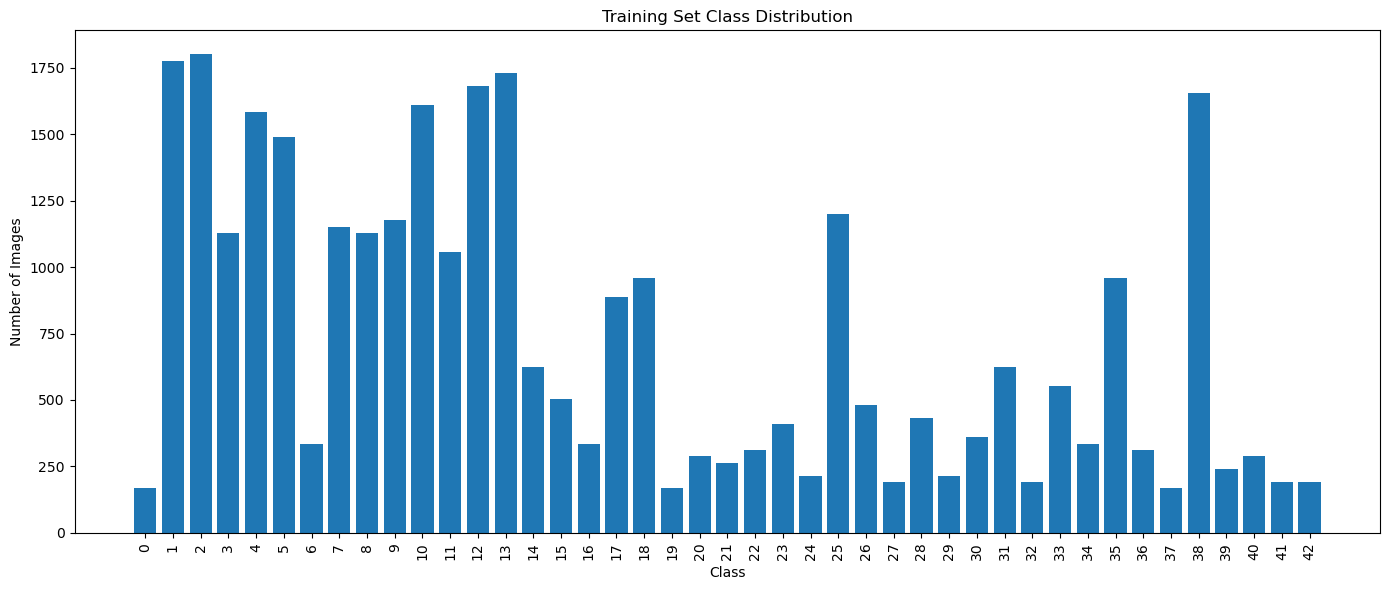

Class distribution figure saved to:
/Users/liuyuhan/Desktop/traffic_recognition/results/figures/hog_svm_training_class_distribution.png


In [16]:
# Plot the training class distribution
plt.figure(figsize=(14, 6))

plt.bar(
    dataset_counts_df["class_name"],
    dataset_counts_df["train_count"]
)

plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.tight_layout()

class_distribution_path = (
    FIGURES_DIR / "hog_svm_training_class_distribution.png"
)

plt.savefig(
    class_distribution_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Class distribution figure saved to:")
print(class_distribution_path)

##### 6. Image and HOG Configuration

All images are resized to 64 × 64 pixels before HOG feature extraction.

HOG configuration:

- 9 gradient orientations;
- 8 × 8 pixels per cell;
- 2 × 2 cells per block;
- L2-Hys block normalisation.

For the final experiment, `MAX_IMAGES_PER_CLASS` should remain `None`.

A small number may temporarily be used for testing the notebook.

In [17]:
IMAGE_SIZE = (64, 64)

HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
HOG_BLOCK_NORM = "L2-Hys"

MAX_IMAGES_PER_CLASS = None

print("Image size:", IMAGE_SIZE)
print("HOG orientations:", HOG_ORIENTATIONS)
print("HOG pixels per cell:", HOG_PIXELS_PER_CELL)
print("HOG cells per block:", HOG_CELLS_PER_BLOCK)
print("Maximum images per class:", MAX_IMAGES_PER_CLASS)

Image size: (64, 64)
HOG orientations: 9
HOG pixels per cell: (8, 8)
HOG cells per block: (2, 2)
Maximum images per class: None


##### 7. Load Images From the CSV Files

For every image:

1. resolve the stored path;
2. open the image;
3. convert it to RGB;
4. resize it to 64 × 64;
5. convert it to a NumPy array;
6. normalise pixel values from `[0, 255]` to `[0, 1]`;
7. convert the class name into an integer label.

In [18]:
def load_image_dataset_from_csv(
    dataframe,
    path_column,
    label_column,
    class_to_index,
    image_size=(64, 64),
    max_images_per_class=None
):
    
    working_df = dataframe.copy()

    working_df[label_column] = (
        working_df[label_column].astype(str)
    )

    if max_images_per_class is not None:
        working_df = (
            working_df
            .groupby(
                label_column,
                group_keys=False
            )
            .head(max_images_per_class)
            .reset_index(drop=True)
        )

    images = []
    labels = []
    file_paths = []
    failed_files = []

    total_rows = len(working_df)

    for processed_count, (_, row) in enumerate(
        working_df.iterrows(),
        start=1
    ):
        stored_path = row[path_column]
        class_name = str(row[label_column])

        resolved_path = resolve_image_path(stored_path)

        try:
            if not resolved_path.exists():
                raise FileNotFoundError(
                    f"Image does not exist: {resolved_path}"
                )

            if class_name not in class_to_index:
                raise ValueError(
                    f"Unknown class label: {class_name}"
                )

            with Image.open(resolved_path) as image:
                image = image.convert("RGB")

                image = image.resize(
                    image_size,
                    Image.Resampling.LANCZOS
                )

                image_array = np.asarray(
                    image,
                    dtype=np.float32
                )

                image_array = image_array / 255.0

                images.append(image_array)
                labels.append(class_to_index[class_name])
                file_paths.append(str(resolved_path))

        except (
            UnidentifiedImageError,
            OSError,
            ValueError,
            FileNotFoundError
        ) as error:
            failed_files.append({
                "stored_path": str(stored_path),
                "resolved_path": str(resolved_path),
                "label": class_name,
                "error": str(error)
            })

        if (
            processed_count % 1000 == 0
            or processed_count == total_rows
        ):
            print(
                f"Processed {processed_count}/{total_rows} images"
            )

    images = np.asarray(
        images,
        dtype=np.float32
    )

    labels = np.asarray(
        labels,
        dtype=np.int32
    )

    return images, labels, file_paths, failed_files


print("CSV-based image loading function created successfully.")

CSV-based image loading function created successfully.


In [19]:
# Load training images
print("Loading the training dataset...\n")

train_load_start = time.perf_counter()

X_train_images, y_train, train_file_paths, train_failed_files = (
    load_image_dataset_from_csv(
        dataframe=train_df,
        path_column=PATH_COLUMN,
        label_column=LABEL_COLUMN,
        class_to_index=CLASS_TO_INDEX,
        image_size=IMAGE_SIZE,
        max_images_per_class=MAX_IMAGES_PER_CLASS
    )
)

train_load_time = time.perf_counter() - train_load_start

print("\nTraining dataset loaded.")
print("Training image array shape:", X_train_images.shape)
print("Training label array shape:", y_train.shape)
print(f"Training loading time: {train_load_time:.2f} seconds")
print("Failed training files:", len(train_failed_files))

Loading the training dataset...

Processed 1000/31367 images
Processed 2000/31367 images
Processed 3000/31367 images
Processed 4000/31367 images
Processed 5000/31367 images
Processed 6000/31367 images
Processed 7000/31367 images
Processed 8000/31367 images
Processed 9000/31367 images
Processed 10000/31367 images
Processed 11000/31367 images
Processed 12000/31367 images
Processed 13000/31367 images
Processed 14000/31367 images
Processed 15000/31367 images
Processed 16000/31367 images
Processed 17000/31367 images
Processed 18000/31367 images
Processed 19000/31367 images
Processed 20000/31367 images
Processed 21000/31367 images
Processed 22000/31367 images
Processed 23000/31367 images
Processed 24000/31367 images
Processed 25000/31367 images
Processed 26000/31367 images
Processed 27000/31367 images
Processed 28000/31367 images
Processed 29000/31367 images
Processed 30000/31367 images
Processed 31000/31367 images
Processed 31367/31367 images

Training dataset loaded.
Training image array s

In [20]:
# Load validation images
print("Loading the validation dataset...\n")

val_load_start = time.perf_counter()

X_val_images, y_val, val_file_paths, val_failed_files = (
    load_image_dataset_from_csv(
        dataframe=val_df,
        path_column=PATH_COLUMN,
        label_column=LABEL_COLUMN,
        class_to_index=CLASS_TO_INDEX,
        image_size=IMAGE_SIZE,
        max_images_per_class=MAX_IMAGES_PER_CLASS
    )
)

val_load_time = time.perf_counter() - val_load_start

print("\nValidation dataset loaded.")
print("Validation image array shape:", X_val_images.shape)
print("Validation label array shape:", y_val.shape)
print(f"Validation loading time: {val_load_time:.2f} seconds")
print("Failed validation files:", len(val_failed_files))

Loading the validation dataset...

Processed 1000/7842 images
Processed 2000/7842 images
Processed 3000/7842 images
Processed 4000/7842 images
Processed 5000/7842 images
Processed 6000/7842 images
Processed 7000/7842 images
Processed 7842/7842 images

Validation dataset loaded.
Validation image array shape: (7842, 64, 64, 3)
Validation label array shape: (7842,)
Validation loading time: 13.57 seconds
Failed validation files: 0


In [21]:
# Load test images
print("Loading the test dataset...\n")

test_load_start = time.perf_counter()

X_test_images, y_test, test_file_paths, test_failed_files = (
    load_image_dataset_from_csv(
        dataframe=test_df,
        path_column=PATH_COLUMN,
        label_column=LABEL_COLUMN,
        class_to_index=CLASS_TO_INDEX,
        image_size=IMAGE_SIZE,
        max_images_per_class=MAX_IMAGES_PER_CLASS
    )
)

test_load_time = time.perf_counter() - test_load_start

print("\nTest dataset loaded.")
print("Test image array shape:", X_test_images.shape)
print("Test label array shape:", y_test.shape)
print(f"Test loading time: {test_load_time:.2f} seconds")
print("Failed test files:", len(test_failed_files))

Loading the test dataset...

Processed 1000/12630 images
Processed 2000/12630 images
Processed 3000/12630 images
Processed 4000/12630 images
Processed 5000/12630 images
Processed 6000/12630 images
Processed 7000/12630 images
Processed 8000/12630 images
Processed 9000/12630 images
Processed 10000/12630 images
Processed 11000/12630 images
Processed 12000/12630 images
Processed 12630/12630 images

Test dataset loaded.
Test image array shape: (12630, 64, 64, 3)
Test label array shape: (12630,)
Test loading time: 17.99 seconds
Failed test files: 0


In [22]:
# Dataset consistency checks
assert len(X_train_images) == len(y_train), (
    "Training images and labels have different lengths."
)

assert len(X_val_images) == len(y_val), (
    "Validation images and labels have different lengths."
)

assert len(X_test_images) == len(y_test), (
    "Test images and labels have different lengths."
)

expected_image_shape = (IMAGE_SIZE[1], IMAGE_SIZE[0], 3)

assert X_train_images.shape[1:] == expected_image_shape, (
    f"Unexpected training image shape: "
    f"{X_train_images.shape[1:]}"
)

assert X_val_images.shape[1:] == expected_image_shape, (
    f"Unexpected validation image shape: "
    f"{X_val_images.shape[1:]}"
)

assert X_test_images.shape[1:] == expected_image_shape, (
    f"Unexpected test image shape: "
    f"{X_test_images.shape[1:]}"
)

print("Dataset consistency checks passed.")

Dataset consistency checks passed.


In [23]:
# Save failed image information
all_failed_files = (train_failed_files + val_failed_files + test_failed_files)

if all_failed_files:
    failed_files_df = pd.DataFrame(all_failed_files)

    failed_files_path = (
        RESULTS_DIR / "hog_svm_failed_image_files.csv"
    )

    failed_files_df.to_csv(
        failed_files_path,
        index=False
    )

    print("Number of failed image files:", len(all_failed_files))
    print("Failure details saved to:")
    print(failed_files_path)

    display(failed_files_df.head(10))

else:
    print("No unreadable image files were found.")

No unreadable image files were found.


In [24]:
# Label distribution summary
def print_label_summary(labels, split_name):
    """
    Print the number of samples and class-size range.
    """
    label_counts = Counter(labels)

    print(f"{split_name} set:")
    print(f"  Number of samples: {len(labels)}")
    print(f"  Number of represented classes: {len(label_counts)}")
    print(f"  Smallest class size: {min(label_counts.values())}")
    print(f"  Largest class size: {max(label_counts.values())}")


print_label_summary(y_train, "Training")
print()
print_label_summary(y_val, "Validation")
print()
print_label_summary(y_test, "Test")

Training set:
  Number of samples: 31367
  Number of represented classes: 43
  Smallest class size: 168
  Largest class size: 1800

Validation set:
  Number of samples: 7842
  Number of represented classes: 43
  Smallest class size: 42
  Largest class size: 450

Test set:
  Number of samples: 12630
  Number of represented classes: 43
  Smallest class size: 60
  Largest class size: 750


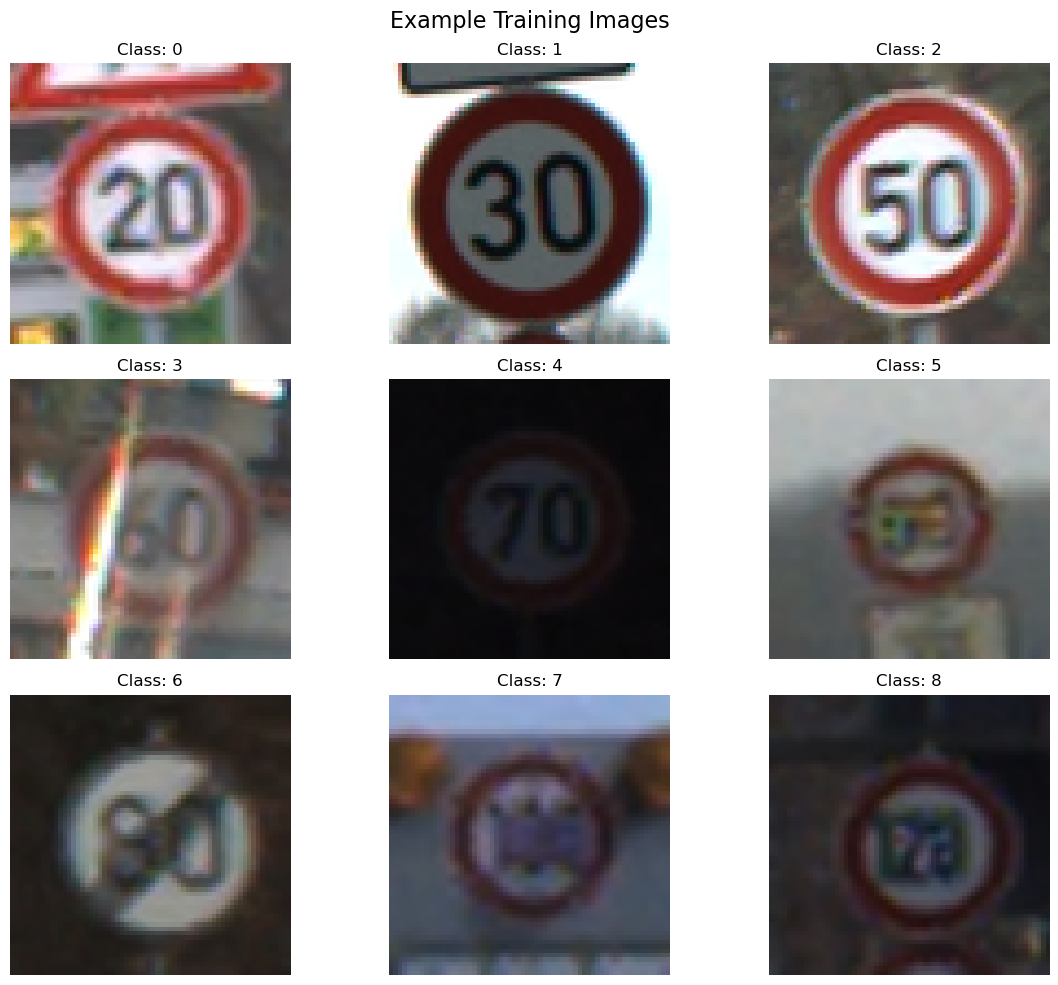

Example-image figure saved to:
/Users/liuyuhan/Desktop/traffic_recognition/results/figures/hog_svm_example_training_images.png


In [25]:
# Display example images
number_of_examples = min(9, NUM_CLASSES)
example_indices = []

for class_index in range(number_of_examples):
    matching_indices = np.where(
        y_train == class_index
    )[0]

    if len(matching_indices) > 0:
        example_indices.append(matching_indices[0])

plt.figure(figsize=(12, 10))

for plot_position, image_index in enumerate(
    example_indices,
    start=1
):
    plt.subplot(3, 3, plot_position)

    plt.imshow(X_train_images[image_index])

    class_index = int(y_train[image_index])
    class_name = INDEX_TO_CLASS[class_index]

    plt.title(f"Class: {class_name}")
    plt.axis("off")

plt.suptitle("Example Training Images", fontsize=16)
plt.tight_layout()

example_images_path = (
    FIGURES_DIR / "hog_svm_example_training_images.png"
)

plt.savefig(
    example_images_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Example-image figure saved to:")
print(example_images_path)

##### 8. HOG Feature Extraction

Histogram of Oriented Gradients describes the distribution of local edge directions within an image.

HOG is suitable for a traditional traffic-image baseline because traffic signs and objects often contain recognisable:

- edges;
- symbols;
- boundaries;
- geometric shapes.

Each image is converted into a one-dimensional numerical feature vector.

In [26]:
def extract_hog_from_image(image):
    """
    Extract a one-dimensional HOG feature vector
    from one RGB image.
    """
    feature_vector = hog(
        image,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm=HOG_BLOCK_NORM,
        transform_sqrt=True,
        feature_vector=True,
        channel_axis=-1
    )

    return feature_vector


example_hog_vector = extract_hog_from_image(X_train_images[0])

print("HOG extraction function created successfully.")
print("Length of one HOG feature vector:",len(example_hog_vector))

HOG extraction function created successfully.
Length of one HOG feature vector: 1764


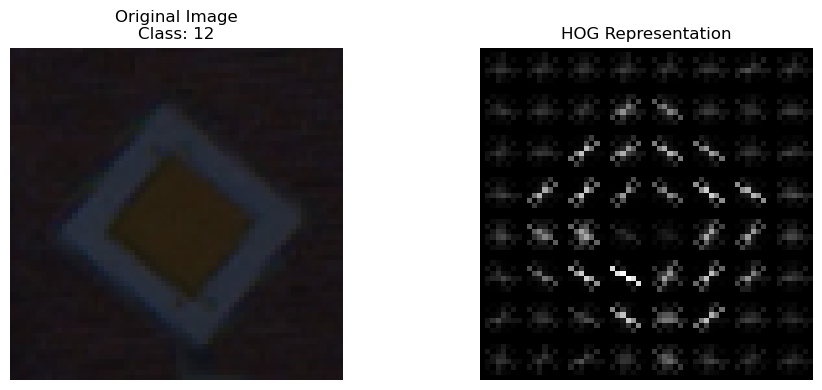

HOG visualisation saved to:
/Users/liuyuhan/Desktop/traffic_recognition/results/figures/hog_svm_hog_visualisation.png


In [27]:
# Visualise one HOG representation
sample_index = 0
sample_image = X_train_images[sample_index]

sample_features, sample_hog_image = hog(
    sample_image,
    orientations=HOG_ORIENTATIONS,
    pixels_per_cell=HOG_PIXELS_PER_CELL,
    cells_per_block=HOG_CELLS_PER_BLOCK,
    block_norm=HOG_BLOCK_NORM,
    transform_sqrt=True,
    visualize=True,
    feature_vector=True,
    channel_axis=-1
)

sample_class_index = int(y_train[sample_index])
sample_class_name = INDEX_TO_CLASS[sample_class_index]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample_image)
plt.title(f"Original Image\nClass: {sample_class_name}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_hog_image, cmap="gray")
plt.title("HOG Representation")
plt.axis("off")

plt.tight_layout()

hog_visualisation_path = (FIGURES_DIR / "hog_svm_hog_visualisation.png")

plt.savefig(
    hog_visualisation_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("HOG visualisation saved to:")
print(hog_visualisation_path)

In [28]:
def extract_hog_dataset(images, split_name="Dataset"):
    """
    Extract HOG features from every image in a dataset.

    Returns
    -------
    numpy.ndarray
        Feature matrix with shape:
        (number_of_images, number_of_hog_features)
    """
    feature_vectors = []

    total_images = len(images)

    for image_index, image in enumerate(
        images,
        start=1
    ):
        feature_vector = extract_hog_from_image(image)
        feature_vectors.append(feature_vector)

        if (
            image_index % 1000 == 0
            or image_index == total_images
        ):
            print(
                f"{split_name}: extracted HOG features for "
                f"{image_index}/{total_images} images"
            )

    return np.asarray(
        feature_vectors,
        dtype=np.float32
    )


print("Batch HOG extraction function created successfully.")

Batch HOG extraction function created successfully.


In [29]:
print("Extracting HOG features from the training set...\n")

train_hog_start = time.perf_counter()

X_train_hog = extract_hog_dataset(X_train_images, split_name="Training")

train_hog_time = time.perf_counter() - train_hog_start

print("\nTraining HOG extraction completed.")
print("Training HOG matrix shape:", X_train_hog.shape)
print(f"Training HOG extraction time: "f"{train_hog_time:.2f} seconds")

Extracting HOG features from the training set...

Training: extracted HOG features for 1000/31367 images
Training: extracted HOG features for 2000/31367 images
Training: extracted HOG features for 3000/31367 images
Training: extracted HOG features for 4000/31367 images
Training: extracted HOG features for 5000/31367 images
Training: extracted HOG features for 6000/31367 images
Training: extracted HOG features for 7000/31367 images
Training: extracted HOG features for 8000/31367 images
Training: extracted HOG features for 9000/31367 images
Training: extracted HOG features for 10000/31367 images
Training: extracted HOG features for 11000/31367 images
Training: extracted HOG features for 12000/31367 images
Training: extracted HOG features for 13000/31367 images
Training: extracted HOG features for 14000/31367 images
Training: extracted HOG features for 15000/31367 images
Training: extracted HOG features for 16000/31367 images
Training: extracted HOG features for 17000/31367 images
Trainin

In [30]:
print("Extracting HOG features from the validation set...\n")

val_hog_start = time.perf_counter()

X_val_hog = extract_hog_dataset(
    X_val_images,
    split_name="Validation"
)

val_hog_time = time.perf_counter() - val_hog_start

print("\nValidation HOG extraction completed.")
print("Validation HOG matrix shape:", X_val_hog.shape)
print(
    f"Validation HOG extraction time: "
    f"{val_hog_time:.2f} seconds"
)

Extracting HOG features from the validation set...

Validation: extracted HOG features for 1000/7842 images
Validation: extracted HOG features for 2000/7842 images
Validation: extracted HOG features for 3000/7842 images
Validation: extracted HOG features for 4000/7842 images
Validation: extracted HOG features for 5000/7842 images
Validation: extracted HOG features for 6000/7842 images
Validation: extracted HOG features for 7000/7842 images
Validation: extracted HOG features for 7842/7842 images

Validation HOG extraction completed.
Validation HOG matrix shape: (7842, 1764)
Validation HOG extraction time: 14.05 seconds


In [31]:
print("Extracting HOG features from the test set...\n")

test_hog_start = time.perf_counter()

X_test_hog = extract_hog_dataset(
    X_test_images,
    split_name="Test"
)

test_hog_time = time.perf_counter() - test_hog_start

print("\nTest HOG extraction completed.")
print("Test HOG matrix shape:", X_test_hog.shape)
print(
    f"Test HOG extraction time: "
    f"{test_hog_time:.2f} seconds"
)

Extracting HOG features from the test set...

Test: extracted HOG features for 1000/12630 images
Test: extracted HOG features for 2000/12630 images
Test: extracted HOG features for 3000/12630 images
Test: extracted HOG features for 4000/12630 images
Test: extracted HOG features for 5000/12630 images
Test: extracted HOG features for 6000/12630 images
Test: extracted HOG features for 7000/12630 images
Test: extracted HOG features for 8000/12630 images
Test: extracted HOG features for 9000/12630 images
Test: extracted HOG features for 10000/12630 images
Test: extracted HOG features for 11000/12630 images
Test: extracted HOG features for 12000/12630 images
Test: extracted HOG features for 12630/12630 images

Test HOG extraction completed.
Test HOG matrix shape: (12630, 1764)
Test HOG extraction time: 22.79 seconds


In [32]:
# Check HOG feature matrices
assert X_train_hog.shape[0] == len(y_train)
assert X_val_hog.shape[0] == len(y_val)
assert X_test_hog.shape[0] == len(y_test)

assert X_train_hog.shape[1] == X_val_hog.shape[1], (
    "Training and validation HOG dimensions differ."
)

assert X_train_hog.shape[1] == X_test_hog.shape[1], (
    "Training and test HOG dimensions differ."
)

NUMBER_OF_HOG_FEATURES = X_train_hog.shape[1]

print("HOG feature consistency checks passed.")
print("Number of HOG features per image:", NUMBER_OF_HOG_FEATURES)

HOG feature consistency checks passed.
Number of HOG features per image: 1764


The classifiers only require the HOG feature matrices, removing the full image arrays reduces memory usage

In [33]:
# Release original image arrays
del X_train_images
del X_val_images
del X_test_images

print("Original image arrays removed from memory.")
print("HOG feature matrices and labels were retained.")

Original image arrays removed from memory.
HOG feature matrices and labels were retained.


##### 9. Evaluation Metrics

The models are evaluated using:

- **Accuracy**: proportion of all predictions that are correct.
- **Macro precision**: precision calculated separately for every class and then averaged.
- **Macro recall**: recall calculated separately for every class and then averaged.
- **Macro F1-score**: F1-score calculated separately for every class and then averaged.
- **Weighted F1-score**: class F1-scores weighted according to class size.

Macro F1 is important for imbalanced multiclass data because every class contributes equally.

In [34]:
def calculate_classification_metrics(y_true, y_pred, model_name, split_name):
    return {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),

        "macro_precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "macro_recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "weighted_f1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    }


def print_classification_metrics(metrics):
    print("Model:", metrics["model"])
    print("Dataset split:", metrics["split"])
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(
        f"Macro precision: "
        f"{metrics['macro_precision']:.4f}"
    )
    print(
        f"Macro recall: "
        f"{metrics['macro_recall']:.4f}"
    )
    print(
        f"Macro F1-score: "
        f"{metrics['macro_f1']:.4f}"
    )
    print(
        f"Weighted F1-score: "
        f"{metrics['weighted_f1']:.4f}"
    )


print("Evaluation functions created successfully.")

Evaluation functions created successfully.


##### 10. Majority-class Dummy Baseline

The dummy classifier always predicts the most common training class.

It does not learn image features. Its purpose is to provide the lowest meaningful reference point for comparison.

In [35]:
# Train dummy classifier
dummy_model = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)

dummy_training_start = time.perf_counter()

dummy_model.fit(X_train_hog, y_train)

dummy_training_time = (time.perf_counter() - dummy_training_start)

print("Majority-class dummy model trained.")
print(f"Training time: "f"{dummy_training_time:.4f} seconds")

Majority-class dummy model trained.
Training time: 0.0053 seconds


In [36]:
# Dummy validation performance
dummy_val_prediction_start = time.perf_counter()

dummy_val_predictions = dummy_model.predict(X_val_hog)

dummy_val_prediction_time = (time.perf_counter() - dummy_val_prediction_start)

dummy_val_metrics = calculate_classification_metrics(
    y_true=y_val,
    y_pred=dummy_val_predictions,
    model_name="Majority Class Dummy",
    split_name="Validation"
)

print_classification_metrics(dummy_val_metrics)

print(f"Validation prediction time: "f"{dummy_val_prediction_time:.4f} seconds")

Model: Majority Class Dummy
Dataset split: Validation
Accuracy: 0.0574
Macro precision: 0.0013
Macro recall: 0.0233
Macro F1-score: 0.0025
Weighted F1-score: 0.0062
Validation prediction time: 0.0029 seconds


In [37]:
# Dummy test performance
dummy_test_prediction_start = time.perf_counter()

dummy_test_predictions = dummy_model.predict(X_test_hog)

dummy_test_prediction_time = (time.perf_counter() - dummy_test_prediction_start)

dummy_test_metrics = calculate_classification_metrics(
    y_true=y_test,
    y_pred=dummy_test_predictions,
    model_name="Majority Class Dummy",
    split_name="Test"
)

print_classification_metrics(dummy_test_metrics)

print(f"Test prediction time: "f"{dummy_test_prediction_time:.4f} seconds")

Model: Majority Class Dummy
Dataset split: Test
Accuracy: 0.0594
Macro precision: 0.0014
Macro recall: 0.0233
Macro F1-score: 0.0026
Weighted F1-score: 0.0067
Test prediction time: 0.0006 seconds


In [38]:
# Identify the majority class
majority_class_index, majority_class_count = (Counter(y_train).most_common(1)[0])

majority_class_name = INDEX_TO_CLASS[majority_class_index]

majority_class_percentage = (majority_class_count / len(y_train)) * 100

print("Majority class index:", majority_class_index)
print("Majority class name:", majority_class_name)
print("Training samples in majority class:", majority_class_count)
print(f"Majority-class proportion: "f"{majority_class_percentage:.2f}%")

Majority class index: 2
Majority class name: 2
Training samples in majority class: 1800
Majority-class proportion: 5.74%


##### 11. HOG + Linear Support Vector Machine

The model pipeline contains:

1. **StandardScaler**
   - Standardises HOG feature values using statistics learned from the training set.

2. **LinearSVC**
   - Learns linear decision boundaries between the classes.

A linear SVM is used because it is more computationally efficient than an RBF-kernel SVM for a large, high-dimensional image dataset.

Balanced class weights are used to reduce bias towards larger classes.

In [39]:
# HOG-SVM PIPELINE
hog_svm_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LinearSVC(
            C=1.0,
            class_weight="balanced",
            max_iter=10000,
            random_state=RANDOM_STATE,
            dual=False
        )
    )
])

print("HOG + Linear SVM pipeline created.")
print()
print(hog_svm_model)

HOG + Linear SVM pipeline created.

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LinearSVC(class_weight='balanced', dual=False, max_iter=10000,
                           random_state=42))])


In [40]:
# Train HOG-SVM model
print("Training the HOG + Linear SVM model...")

svm_training_start = time.perf_counter()

hog_svm_model.fit(X_train_hog, y_train)

svm_training_time = (time.perf_counter() - svm_training_start)

print("\nHOG + Linear SVM training completed.")
print(f"Training time: "f"{svm_training_time:.2f} seconds")

Training the HOG + Linear SVM model...

HOG + Linear SVM training completed.
Training time: 21142.93 seconds


In [41]:
# SVM validation performance
print("Generating validation predictions...")

svm_val_prediction_start = time.perf_counter()

svm_val_predictions = hog_svm_model.predict(X_val_hog)

svm_val_prediction_time = (time.perf_counter() - svm_val_prediction_start)

svm_val_metrics = calculate_classification_metrics(
    y_true=y_val,
    y_pred=svm_val_predictions,
    model_name="HOG + Linear SVM",
    split_name="Validation"
)

print()
print_classification_metrics(svm_val_metrics)

print(f"Validation prediction time: "f"{svm_val_prediction_time:.2f} seconds")

Generating validation predictions...

Model: HOG + Linear SVM
Dataset split: Validation
Accuracy: 0.9494
Macro precision: 0.9555
Macro recall: 0.9606
Macro F1-score: 0.9579
Weighted F1-score: 0.9492
Validation prediction time: 0.43 seconds


In [42]:
# SVM test performance
print("Generating test predictions...")

svm_test_prediction_start = time.perf_counter()

svm_test_predictions = hog_svm_model.predict(X_test_hog)

svm_test_prediction_time = (time.perf_counter() - svm_test_prediction_start)

svm_test_metrics = calculate_classification_metrics(
    y_true=y_test,
    y_pred=svm_test_predictions,
    model_name="HOG + Linear SVM",
    split_name="Test"
)

print()
print_classification_metrics(svm_test_metrics)

print(f"Test prediction time: "f"{svm_test_prediction_time:.2f} seconds")

Generating test predictions...

Model: HOG + Linear SVM
Dataset split: Test
Accuracy: 0.8771
Macro precision: 0.8628
Macro recall: 0.8655
Macro F1-score: 0.8623
Weighted F1-score: 0.8765
Test prediction time: 0.75 seconds


##### 12. Classification Reports

The classification report contains class-level:

- precision;
- recall;
- F1-score;
- support.

This makes it possible to identify classes that are easy or difficult for the model.

In [43]:
# Validation classification report
svm_val_report = classification_report(
    y_val,
    svm_val_predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

svm_val_report_df = pd.DataFrame(
    svm_val_report
).transpose()

svm_val_report_path = (
    RESULTS_DIR
    / "hog_svm_validation_classification_report.csv"
)

svm_val_report_df.to_csv(
    svm_val_report_path,
    index=True
)

print("Validation classification report:")
display(svm_val_report_df)

print("\nValidation report saved to:")
print(svm_val_report_path)

Validation classification report:


,precision,recall,f1-score,support
0,0.948718,0.880952,0.913580,42.000000
1,0.880531,0.896396,0.888393,444.000000
2,0.869663,0.860000,0.864804,450.000000
3,0.913043,0.893617,0.903226,282.000000
4,0.958656,0.936869,0.947637,396.000000
5,0.854749,0.822581,0.838356,372.000000
6,0.952941,0.964286,0.958580,84.000000
7,0.907850,0.923611,0.915663,288.000000
8,0.904594,0.907801,0.906195,282.000000
9,0.963333,0.982993,0.973064,294.000000



Validation report saved to:
/Users/liuyuhan/Desktop/traffic_recognition/results/hog_svm_validation_classification_report.csv


In [44]:
# Test classification report
svm_test_report = classification_report(
    y_test,
    svm_test_predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

svm_test_report_df = pd.DataFrame(
    svm_test_report
).transpose()

svm_test_report_path = (
    RESULTS_DIR
    / "hog_svm_test_classification_report.csv"
)

svm_test_report_df.to_csv(
    svm_test_report_path,
    index=True
)

print("Test classification report:")
display(svm_test_report_df)

print("\nTest report saved to:")
print(svm_test_report_path)

Test classification report:


,precision,recall,f1-score,support
0,0.584615,0.633333,0.608000,60.000000
1,0.810585,0.808333,0.809458,720.000000
2,0.767038,0.825333,0.795119,750.000000
3,0.835381,0.755556,0.793466,450.000000
4,0.913313,0.893939,0.903522,660.000000
5,0.703526,0.696825,0.700159,630.000000
6,0.845070,0.800000,0.821918,150.000000
7,0.860731,0.837778,0.849099,450.000000
8,0.807095,0.808889,0.807991,450.000000
9,0.920000,0.958333,0.938776,480.000000



Test report saved to:
/Users/liuyuhan/Desktop/traffic_recognition/results/hog_svm_test_classification_report.csv


##### 13. Confusion Matrices

In a confusion matrix:

- rows represent the true classes;
- columns represent the predicted classes;
- diagonal values represent correct classifications;
- off-diagonal values represent classification errors.

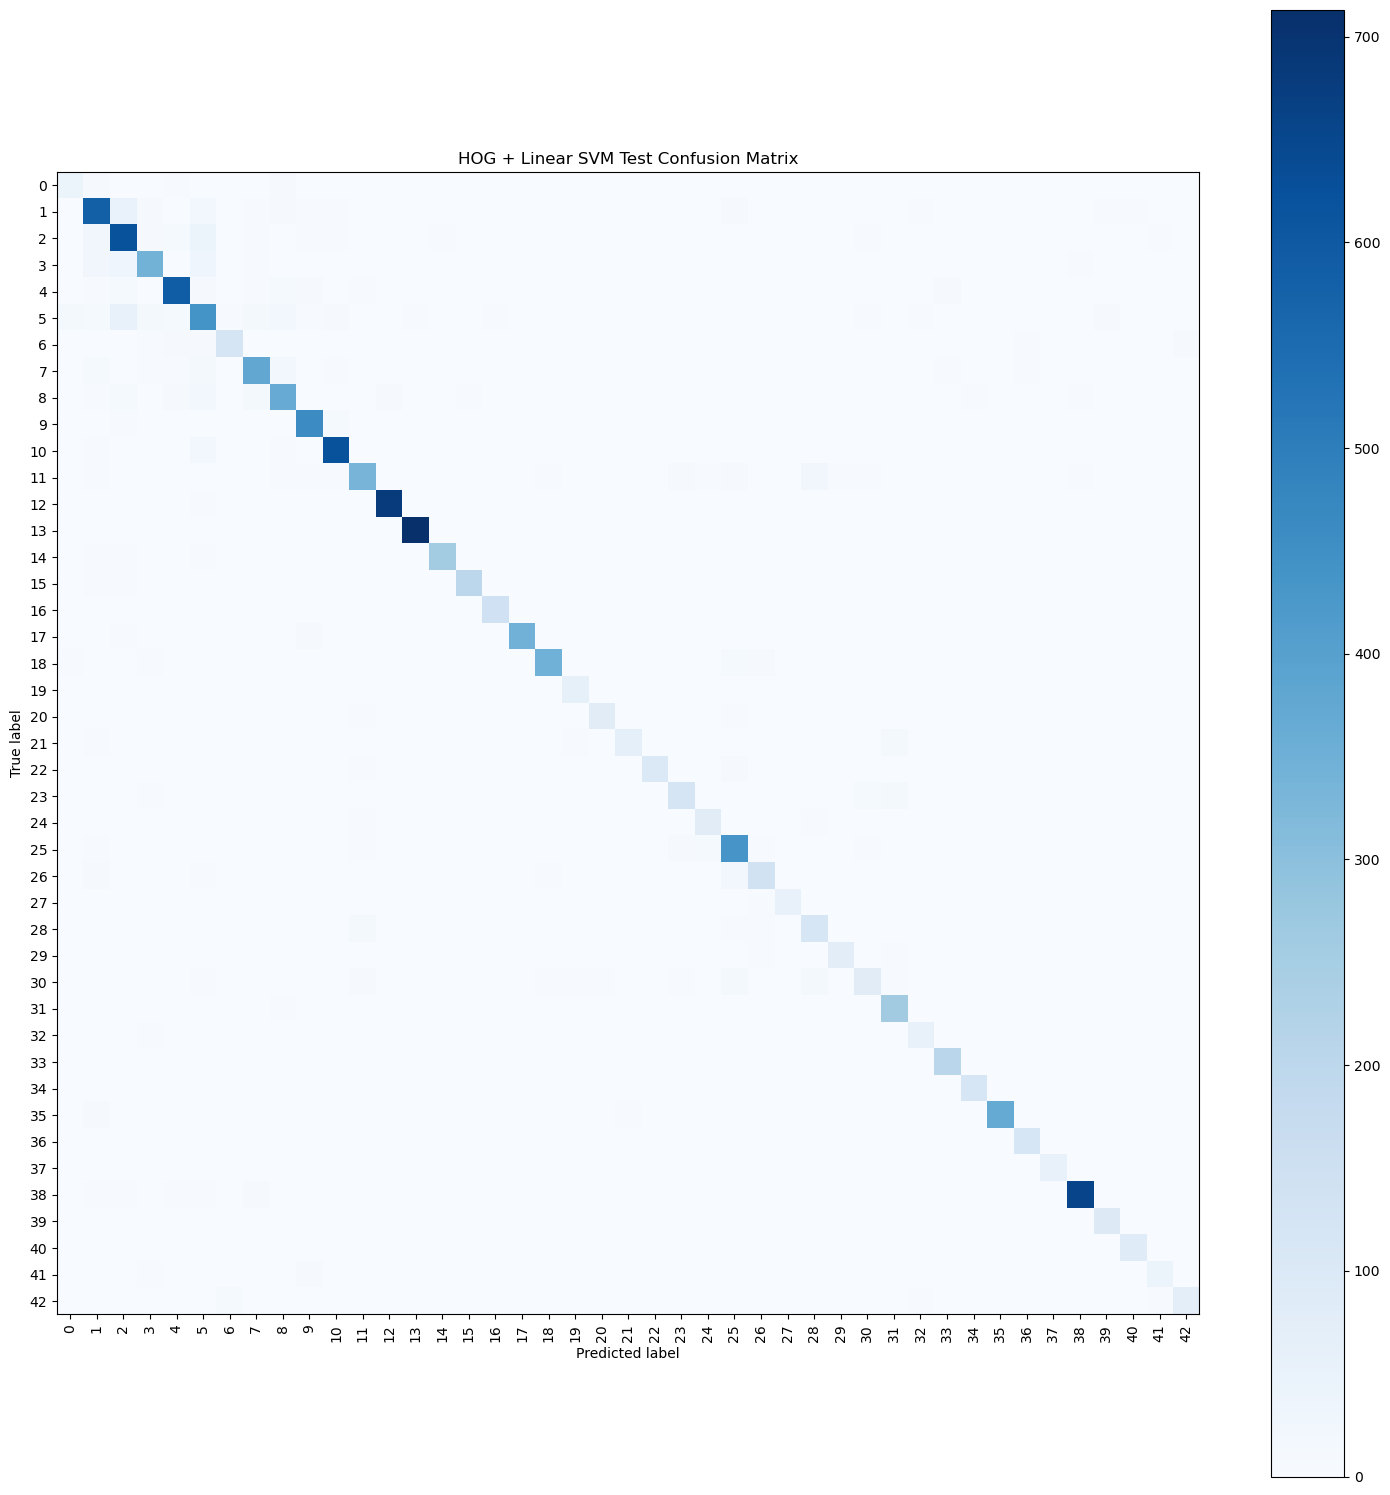

Test confusion matrix saved to:
/Users/liuyuhan/Desktop/traffic_recognition/results/figures/hog_svm_test_confusion_matrix.png


In [45]:
# Raw test confusion matrix
test_confusion_matrix = confusion_matrix(
    y_test,
    svm_test_predictions,
    labels=list(range(NUM_CLASSES))
)

figure_size = max(12,NUM_CLASSES * 0.35)

fig, ax = plt.subplots(figsize=(figure_size, figure_size))

confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_matrix,
    display_labels=CLASS_NAMES
)

# Values are hidden when there are many classes because displaying every number makes the figure unreadable
show_values = NUM_CLASSES <= 20

confusion_display.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=True,
    include_values=show_values,
    values_format="d"
)

plt.title("HOG + Linear SVM Test Confusion Matrix")
plt.tight_layout()

test_confusion_matrix_path = (FIGURES_DIR / "hog_svm_test_confusion_matrix.png")

plt.savefig(test_confusion_matrix_path,dpi=300,bbox_inches="tight")

plt.show()

print("Test confusion matrix saved to:")
print(test_confusion_matrix_path)

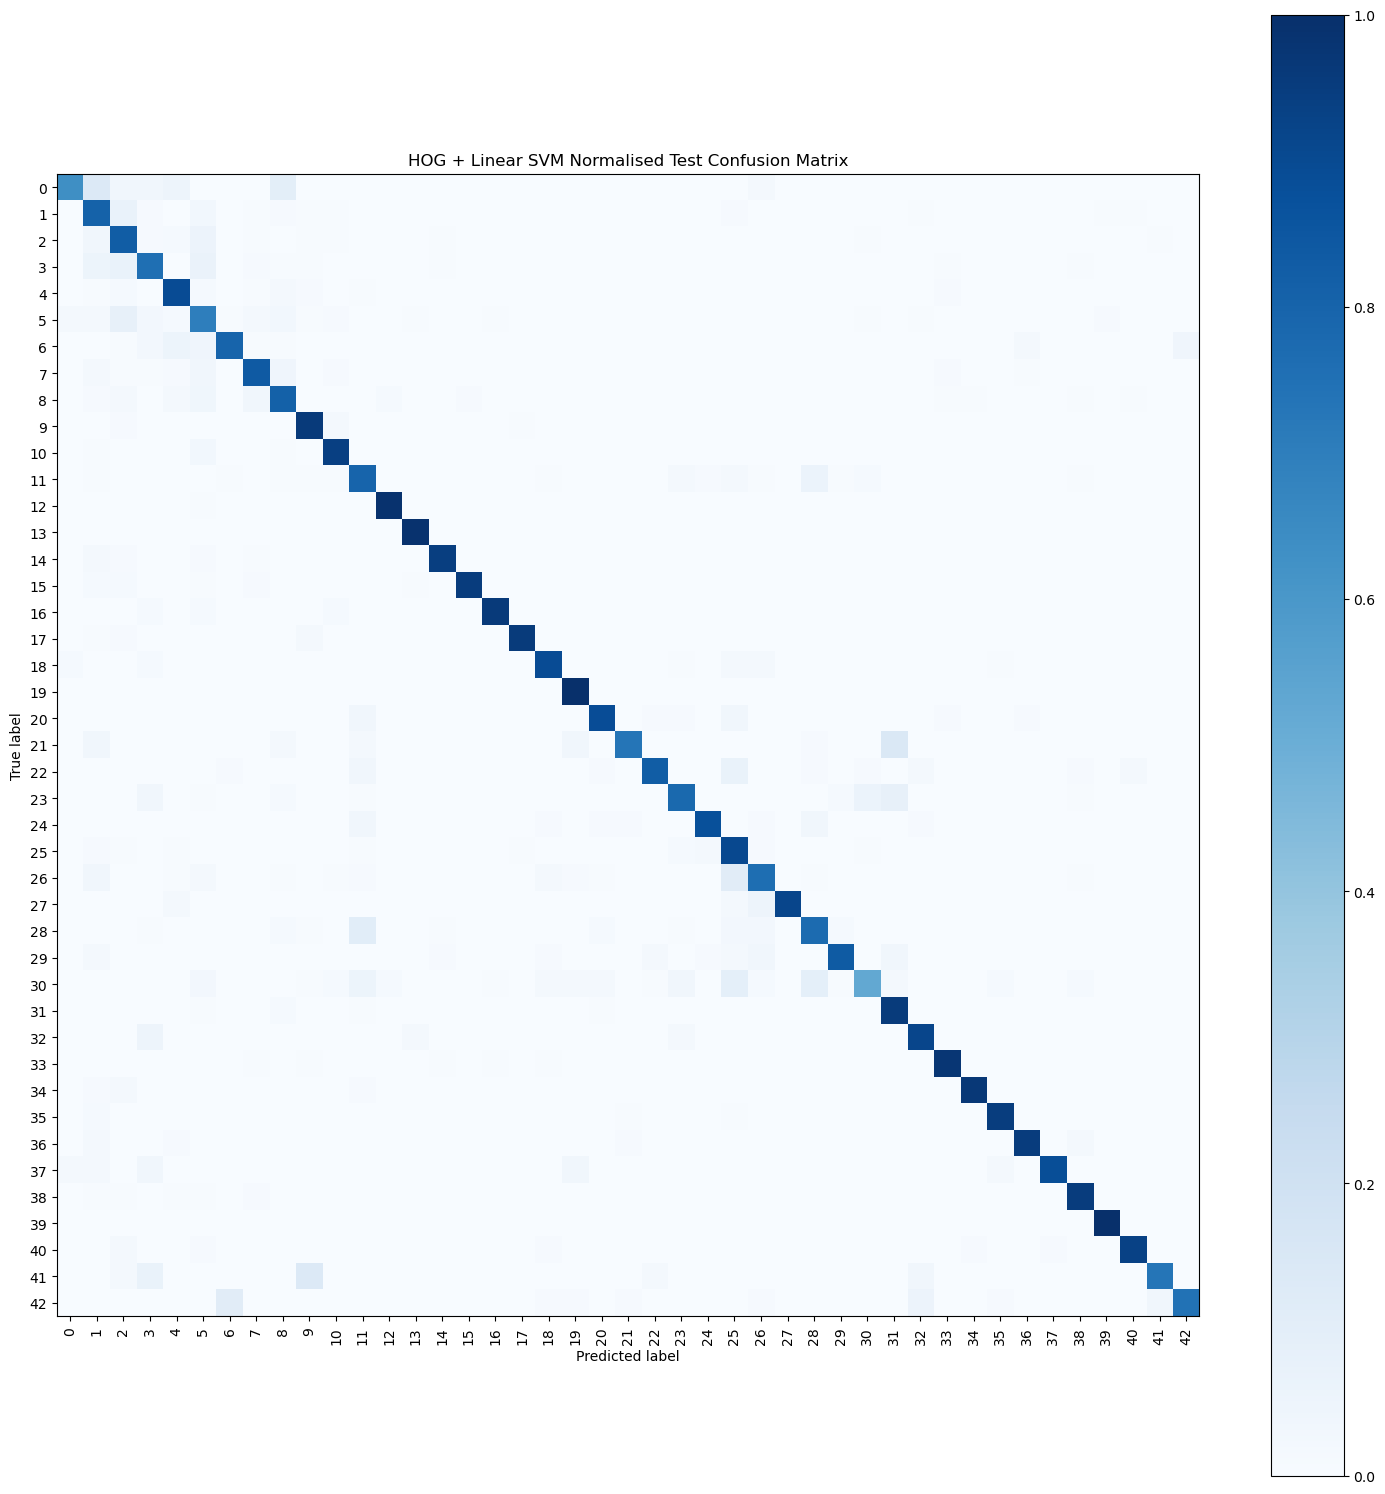

Normalised confusion matrix saved to:
/Users/liuyuhan/Desktop/traffic_recognition/results/figures/hog_svm_test_confusion_matrix_normalised.png


In [46]:
# Normalised test confusion matrix
normalised_test_confusion_matrix = confusion_matrix(
    y_test,
    svm_test_predictions,
    labels=list(range(NUM_CLASSES)),
    normalize="true"
)

fig, ax = plt.subplots(figsize=(figure_size, figure_size))

normalised_display = ConfusionMatrixDisplay(
    confusion_matrix=normalised_test_confusion_matrix,
    display_labels=CLASS_NAMES
)

normalised_display.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=True,
    include_values=show_values,
    values_format=".2f"
)

plt.title("HOG + Linear SVM Normalised Test Confusion Matrix")

plt.tight_layout()

normalised_confusion_matrix_path = (FIGURES_DIR / "hog_svm_test_confusion_matrix_normalised.png")

plt.savefig(normalised_confusion_matrix_path, dpi=300, bbox_inches="tight")

plt.show()

print("Normalised confusion matrix saved to:")
print(normalised_confusion_matrix_path)

##### 14. Per-class Performance

The diagonal of the row-normalised confusion matrix represents recall for each class.

A high value means that most images belonging to that class were identified correctly.

In [47]:
# Pre-class test performance
per_class_recall = np.diag(normalised_test_confusion_matrix)

per_class_performance_df = pd.DataFrame({
    "class_index": list(range(NUM_CLASSES)),
    "class_name": CLASS_NAMES,
    "test_recall": per_class_recall,
    "test_support": [
        int(np.sum(y_test == class_index))
        for class_index in range(NUM_CLASSES)
    ]
})

per_class_performance_df = (
    per_class_performance_df
    .sort_values(
        by="test_recall",
        ascending=False
    )
    .reset_index(drop=True)
)

per_class_performance_path = (RESULTS_DIR / "hog_svm_per_class_test_performance.csv")

per_class_performance_df.to_csv(per_class_performance_path, index=False)

display(per_class_performance_df)

print("\nPer-class performance saved to:")
print(per_class_performance_path)

,class_index,class_name,test_recall,test_support
0,19,19,1.000000,60
1,39,39,1.000000,90
2,13,13,0.990278,720
3,12,12,0.988406,690
4,33,33,0.976190,210
5,34,34,0.966667,120
6,16,16,0.960000,150
7,9,9,0.958333,480
8,17,17,0.955556,360
9,31,31,0.955556,270



Per-class performance saved to:
/Users/liuyuhan/Desktop/traffic_recognition/results/hog_svm_per_class_test_performance.csv


In [48]:
# Best and worst classes
number_to_show = min(5, NUM_CLASSES)

best_classes_df = per_class_performance_df.head(number_to_show)

worst_classes_df = (
    per_class_performance_df
    .tail(number_to_show)
    .sort_values(
        by="test_recall",
        ascending=True
    )
)

print(f"Top {number_to_show} classes by test recall:")
display(best_classes_df)

print(f"\nBottom {number_to_show} classes by test recall:")
display(worst_classes_df)

Top 5 classes by test recall:


,class_index,class_name,test_recall,test_support
0,19,19,1.000000,60
1,39,39,1.000000,90
2,13,13,0.990278,720
3,12,12,0.988406,690
4,33,33,0.976190,210



Bottom 5 classes by test recall:


,class_index,class_name,test_recall,test_support
42,30,30,0.526667,150
41,0,0,0.633333,60
40,5,5,0.696825,630
39,41,41,0.733333,60
38,21,21,0.733333,90


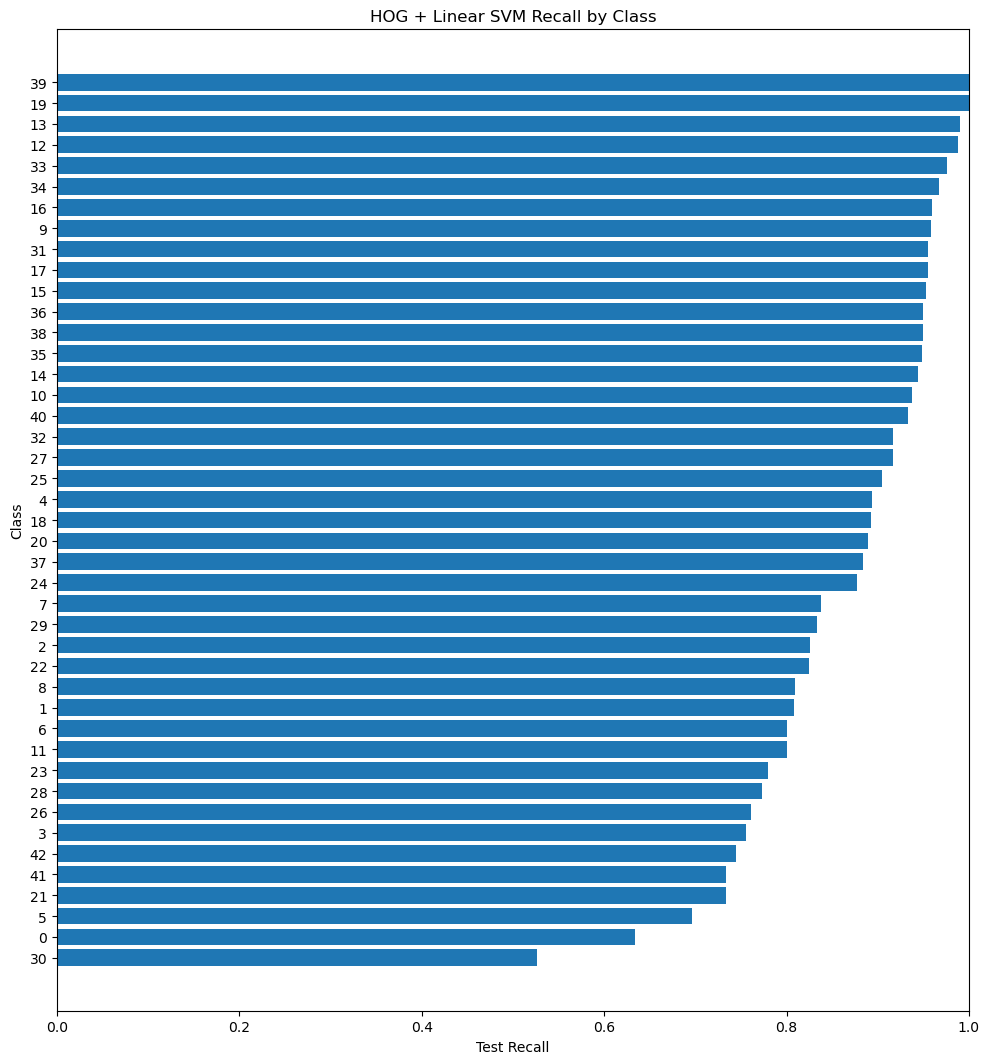

Per-class recall figure saved to:
/Users/liuyuhan/Desktop/traffic_recognition/results/figures/hog_svm_test_recall_by_class.png


In [49]:
# Plot test recall by class
recall_plot_df = per_class_performance_df.sort_values(by="test_recall", ascending=True)

plt.figure(figsize=(10, max(6, NUM_CLASSES * 0.25)))

plt.barh(recall_plot_df["class_name"], recall_plot_df["test_recall"])

plt.xlabel("Test Recall")
plt.ylabel("Class")
plt.title("HOG + Linear SVM Recall by Class")
plt.xlim(0, 1)
plt.tight_layout()

per_class_recall_figure_path = (FIGURES_DIR / "hog_svm_test_recall_by_class.png")

plt.savefig(per_class_recall_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Per-class recall figure saved to:")
print(per_class_recall_figure_path)

##### 15. Model Comparison

The dummy classifier and HOG-SVM model are compared using the same validation and test splits.

In [50]:
# Combine model metrics
all_metrics = [
    dummy_val_metrics,
    dummy_test_metrics,
    svm_val_metrics,
    svm_test_metrics
]

metrics_df = pd.DataFrame(all_metrics)

timing_lookup = {
    ("Majority Class Dummy", "Validation"): {
        "training_time_seconds": dummy_training_time,
        "prediction_time_seconds": dummy_val_prediction_time
    },

    ("Majority Class Dummy", "Test"): {
        "training_time_seconds": dummy_training_time,
        "prediction_time_seconds": dummy_test_prediction_time
    },

    ("HOG + Linear SVM", "Validation"): {
        "training_time_seconds": svm_training_time,
        "prediction_time_seconds": svm_val_prediction_time
    },

    ("HOG + Linear SVM", "Test"): {
        "training_time_seconds": svm_training_time,
        "prediction_time_seconds": svm_test_prediction_time
    }
}

metrics_df["training_time_seconds"] = metrics_df.apply(
    lambda row: timing_lookup[
        (row["model"], row["split"])
    ]["training_time_seconds"],
    axis=1
)

metrics_df["prediction_time_seconds"] = metrics_df.apply(
    lambda row: timing_lookup[
        (row["model"], row["split"])
    ]["prediction_time_seconds"],
    axis=1
)

metrics_path = (RESULTS_DIR / "hog_svm_baseline_model_metrics.csv")

metrics_df.to_csv(metrics_path, index=False)

display(metrics_df.round(4))

print("\nModel metrics saved to:")
print(metrics_path)

,model,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_time_seconds,prediction_time_seconds
0,Majority Class Dummy,Validation,0.0574,0.0013,0.0233,0.0025,0.0062,0.0053,0.0029
1,Majority Class Dummy,Test,0.0594,0.0014,0.0233,0.0026,0.0067,0.0053,0.0006
2,HOG + Linear SVM,Validation,0.9494,0.9555,0.9606,0.9579,0.9492,21142.9302,0.4303
3,HOG + Linear SVM,Test,0.8771,0.8628,0.8655,0.8623,0.8765,21142.9302,0.7525



Model metrics saved to:
/Users/liuyuhan/Desktop/traffic_recognition/results/hog_svm_baseline_model_metrics.csv


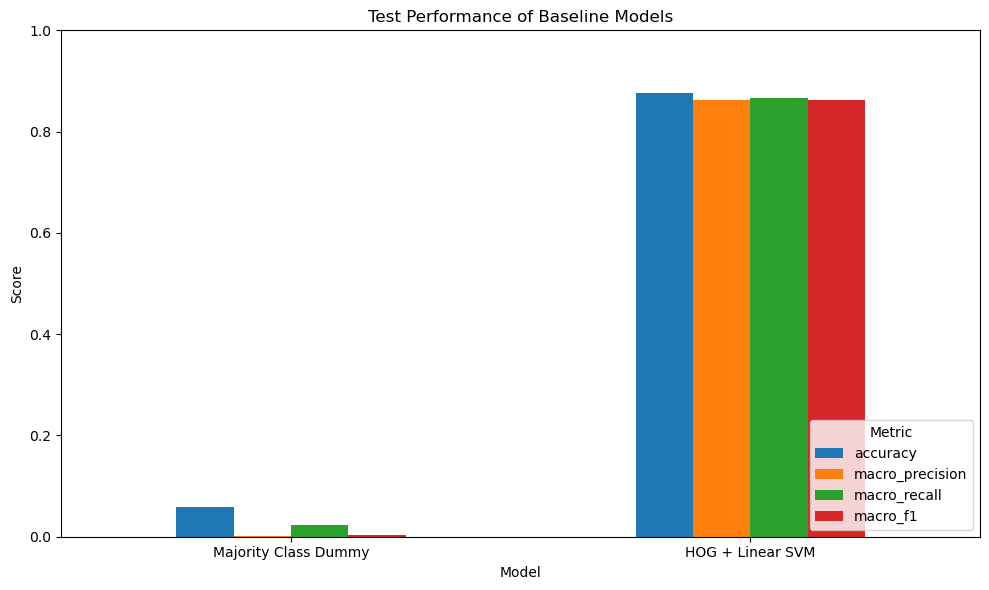

Model comparison figure saved to:
/Users/liuyuhan/Desktop/traffic_recognition/results/figures/hog_svm_baseline_model_comparison.png


In [51]:
# Test model comparision figure
test_comparison_df = metrics_df[metrics_df["split"] == "Test"].copy()

comparison_metrics = [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1"
]

comparison_plot_df = (
    test_comparison_df[
        ["model"] + comparison_metrics
    ]
    .set_index("model")
)

comparison_plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Test Performance of Baseline Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric",loc="lower right")
plt.tight_layout()

model_comparison_figure_path = (FIGURES_DIR / "hog_svm_baseline_model_comparison.png")

plt.savefig(model_comparison_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Model comparison figure saved to:")
print(model_comparison_figure_path)

In [52]:
# Validation-Test performance gap
accuracy_gap = (svm_val_metrics["accuracy"] - svm_test_metrics["accuracy"])

macro_f1_gap = (svm_val_metrics["macro_f1"] - svm_test_metrics["macro_f1"])

print("Validation accuracy minus test accuracy:", f"{accuracy_gap:.4f}")

print("Validation macro F1 minus test macro F1:", f"{macro_f1_gap:.4f}")

if abs(accuracy_gap) < 0.05:
    print(
        "\nValidation and test accuracy are reasonably close."
    )
else:
    print(
        "\nThere is a noticeable validation-test accuracy gap. "
        "This may indicate differences between the splits or "
        "limited model generalisation."
    )

Validation accuracy minus test accuracy: 0.0723
Validation macro F1 minus test macro F1: 0.0955

There is a noticeable validation-test accuracy gap. This may indicate differences between the splits or limited model generalisation.


##### 16. Save the Trained Model

The complete pipeline is saved, including:

- the fitted feature scaler;
- the trained Linear SVM classifier.

The HOG settings and class mappings are saved separately in JSON format.

In [53]:
# Save trained model
hog_svm_model_path = (MODEL_DIR / "hog_linear_svm_baseline.joblib")

joblib.dump(hog_svm_model, hog_svm_model_path)

print("Trained HOG + Linear SVM model saved to:")
print(hog_svm_model_path)

Trained HOG + Linear SVM model saved to:
/Users/liuyuhan/Desktop/traffic_recognition/models/hog_linear_svm_baseline.joblib


In [54]:
# Save model configuration
model_configuration = {
    "model_name": "HOG + Linear SVM",
    "random_state": RANDOM_STATE,

    "image_size": list(IMAGE_SIZE),

    "number_of_classes": int(NUM_CLASSES),

    "number_of_hog_features": int(
        NUMBER_OF_HOG_FEATURES
    ),

    "class_to_index": CLASS_TO_INDEX,

    "index_to_class": {
        str(index): class_name
        for index, class_name in INDEX_TO_CLASS.items()
    },

    "hog_parameters": {
        "orientations": HOG_ORIENTATIONS,
        "pixels_per_cell": list(HOG_PIXELS_PER_CELL),
        "cells_per_block": list(HOG_CELLS_PER_BLOCK),
        "block_norm": HOG_BLOCK_NORM,
        "transform_sqrt": True,
        "channel_axis": -1
    },

    "svm_parameters": {
        "C": 1.0,
        "class_weight": "balanced",
        "max_iter": 10000,
        "dual": False
    },

    "dataset": {
        "training_samples": int(len(y_train)),
        "validation_samples": int(len(y_val)),
        "test_samples": int(len(y_test))
    },

    "performance": {
        "validation_accuracy": float(
            svm_val_metrics["accuracy"]
        ),

        "validation_macro_f1": float(
            svm_val_metrics["macro_f1"]
        ),

        "test_accuracy": float(
            svm_test_metrics["accuracy"]
        ),

        "test_macro_f1": float(
            svm_test_metrics["macro_f1"]
        )
    },

    "timing": {
        "training_seconds": float(
            svm_training_time
        ),

        "test_prediction_seconds": float(
            svm_test_prediction_time
        )
    }
}

configuration_path = (MODEL_DIR / "hog_linear_svm_configuration.json")

with open(
    configuration_path,
    "w",
    encoding="utf-8"
) as configuration_file:
    json.dump(
        model_configuration,
        configuration_file,
        indent=4,
        ensure_ascii=False
    )

print("Model configuration saved to:")
print(configuration_path)

Model configuration saved to:
/Users/liuyuhan/Desktop/traffic_recognition/models/hog_linear_svm_configuration.json


In [55]:
# Verify saved model
reloaded_hog_svm_model = joblib.load(hog_svm_model_path)

number_of_reload_test_samples = min(10, len(X_test_hog))

reload_test_predictions = (
    reloaded_hog_svm_model.predict(
        X_test_hog[:number_of_reload_test_samples]
    )
)

original_test_predictions = (
    svm_test_predictions[
        :number_of_reload_test_samples
    ]
)

assert np.array_equal(
    reload_test_predictions,
    original_test_predictions
), (
    "Reloaded model predictions do not match "
    "the original predictions."
)

print("Saved model reloaded successfully.")
print("Reloaded predictions match the original predictions.")

Saved model reloaded successfully.
Reloaded predictions match the original predictions.


##### 17. Save Individual Test Predictions

Saving each prediction allows later inspection of:

- correctly classified images;
- incorrectly classified images;
- common confusion pairs;
- difficult classes.

In [56]:
# Save test predictions
test_predictions_df = pd.DataFrame({
    "file_path": test_file_paths,

    "true_class_index": y_test,

    "true_class_name": [
        INDEX_TO_CLASS[int(label)]
        for label in y_test
    ],

    "predicted_class_index": svm_test_predictions,

    "predicted_class_name": [
        INDEX_TO_CLASS[int(label)]
        for label in svm_test_predictions
    ]
})

test_predictions_df["correct"] = (
    test_predictions_df["true_class_index"]
    == test_predictions_df["predicted_class_index"]
)

test_predictions_path = (
    RESULTS_DIR / "hog_svm_test_predictions.csv"
)

test_predictions_df.to_csv(
    test_predictions_path,
    index=False
)

display(test_predictions_df.head(10))

print("\nTest predictions saved to:")
print(test_predictions_path)

,file_path,true_class_index,true_class_name,predicted_class_index,predicted_class_name,correct
0,/Users/liuyuhan/Desktop/traffic_recognition/da...,16,16,16,16,True
1,/Users/liuyuhan/Desktop/traffic_recognition/da...,1,1,1,1,True
2,/Users/liuyuhan/Desktop/traffic_recognition/da...,38,38,38,38,True
3,/Users/liuyuhan/Desktop/traffic_recognition/da...,33,33,33,33,True
4,/Users/liuyuhan/Desktop/traffic_recognition/da...,11,11,11,11,True
5,/Users/liuyuhan/Desktop/traffic_recognition/da...,38,38,38,38,True
6,/Users/liuyuhan/Desktop/traffic_recognition/da...,18,18,18,18,True
7,/Users/liuyuhan/Desktop/traffic_recognition/da...,12,12,12,12,True
8,/Users/liuyuhan/Desktop/traffic_recognition/da...,25,25,25,25,True
9,/Users/liuyuhan/Desktop/traffic_recognition/da...,35,35,35,35,True



Test predictions saved to:
/Users/liuyuhan/Desktop/traffic_recognition/results/hog_svm_test_predictions.csv


In [57]:
# Common classification errors
incorrect_predictions_df = test_predictions_df[test_predictions_df["correct"] == False].copy()

if len(incorrect_predictions_df) > 0:
    common_errors_df = (
        incorrect_predictions_df
        .groupby([
            "true_class_name",
            "predicted_class_name"
        ])
        .size()
        .reset_index(name="error_count")
        .sort_values(
            by="error_count",
            ascending=False
        )
        .reset_index(drop=True)
    )

    common_errors_path = (RESULTS_DIR / "hog_svm_common_classification_errors.csv")

    common_errors_df.to_csv(common_errors_path, index=False)

    print("Most common classification errors:")
    display(common_errors_df.head(15))

    print("\nClassification errors saved to:")
    print(common_errors_path)

else:
    common_errors_df = pd.DataFrame()

    print("The model made no incorrect test predictions.")

Most common classification errors:


,true_class_name,predicted_class_name,error_count
0,5,2,51
1,1,2,50
2,2,5,42
3,3,2,31
4,3,5,29
5,11,28,25
6,2,1,25
7,3,1,23
8,1,5,22
9,26,25,20



Classification errors saved to:
/Users/liuyuhan/Desktop/traffic_recognition/results/hog_svm_common_classification_errors.csv


In [58]:
# Save experiment summary
experiment_summary = {
    "dataset": {
        "training_samples": int(len(y_train)),
        "validation_samples": int(len(y_val)),
        "test_samples": int(len(y_test)),
        "number_of_classes": int(NUM_CLASSES)
    },

    "feature_extraction": {
        "method": "Histogram of Oriented Gradients",

        "number_of_features": int(
            NUMBER_OF_HOG_FEATURES
        ),

        "training_extraction_seconds": float(
            train_hog_time
        ),

        "validation_extraction_seconds": float(
            val_hog_time
        ),

        "test_extraction_seconds": float(
            test_hog_time
        )
    },

    "dummy_baseline": {
        "validation_accuracy": float(
            dummy_val_metrics["accuracy"]
        ),

        "validation_macro_f1": float(
            dummy_val_metrics["macro_f1"]
        ),

        "test_accuracy": float(
            dummy_test_metrics["accuracy"]
        ),

        "test_macro_f1": float(
            dummy_test_metrics["macro_f1"]
        )
    },

    "hog_svm": {
        "validation_accuracy": float(
            svm_val_metrics["accuracy"]
        ),

        "validation_macro_f1": float(
            svm_val_metrics["macro_f1"]
        ),

        "test_accuracy": float(
            svm_test_metrics["accuracy"]
        ),

        "test_macro_precision": float(
            svm_test_metrics["macro_precision"]
        ),

        "test_macro_recall": float(
            svm_test_metrics["macro_recall"]
        ),

        "test_macro_f1": float(
            svm_test_metrics["macro_f1"]
        ),

        "test_weighted_f1": float(
            svm_test_metrics["weighted_f1"]
        ),

        "training_seconds": float(
            svm_training_time
        ),

        "test_prediction_seconds": float(
            svm_test_prediction_time
        )
    }
}

experiment_summary_path = (RESULTS_DIR / "hog_svm_baseline_experiment_summary.json")

with open(
    experiment_summary_path,
    "w",
    encoding="utf-8"
) as summary_file:
    json.dump(
        experiment_summary,
        summary_file,
        indent=4,
        ensure_ascii=False
    )

print("Experiment summary saved to:")
print(experiment_summary_path)

Experiment summary saved to:
/Users/liuyuhan/Desktop/traffic_recognition/results/hog_svm_baseline_experiment_summary.json


##### 18. Final Experiment Summary

The following cell prints the main results required for the project report.

In [59]:
accuracy_improvement = (svm_test_metrics["accuracy"] - dummy_test_metrics["accuracy"])

macro_f1_improvement = (svm_test_metrics["macro_f1"] - dummy_test_metrics["macro_f1"])

print("=" * 70)
print("FINAL MACHINE LEARNING BASELINE SUMMARY")
print("=" * 70)

print("\nDataset:")
print(f"  Training samples: {len(y_train)}")
print(f"  Validation samples: {len(y_val)}")
print(f"  Test samples: {len(y_test)}")
print(f"  Number of classes: {NUM_CLASSES}")

print("\nMajority-class dummy baseline:")
print(
    f"  Test accuracy: "
    f"{dummy_test_metrics['accuracy']:.4f}"
)
print(
    f"  Test macro F1: "
    f"{dummy_test_metrics['macro_f1']:.4f}"
)

print("\nHOG + Linear SVM:")
print(
    f"  Validation accuracy: "
    f"{svm_val_metrics['accuracy']:.4f}"
)
print(
    f"  Validation macro F1: "
    f"{svm_val_metrics['macro_f1']:.4f}"
)
print(
    f"  Test accuracy: "
    f"{svm_test_metrics['accuracy']:.4f}"
)
print(
    f"  Test macro precision: "
    f"{svm_test_metrics['macro_precision']:.4f}"
)
print(
    f"  Test macro recall: "
    f"{svm_test_metrics['macro_recall']:.4f}"
)
print(
    f"  Test macro F1: "
    f"{svm_test_metrics['macro_f1']:.4f}"
)
print(
    f"  Test weighted F1: "
    f"{svm_test_metrics['weighted_f1']:.4f}"
)

print("\nImprovement over dummy baseline:")
print(
    f"  Accuracy improvement: "
    f"{accuracy_improvement:.4f}"
)
print(
    f"  Macro F1 improvement: "
    f"{macro_f1_improvement:.4f}"
)

print("\nComputational information:")
print(
    f"  HOG features per image: "
    f"{NUMBER_OF_HOG_FEATURES}"
)
print(
    f"  SVM training time: "
    f"{svm_training_time:.2f} seconds"
)
print(
    f"  Test prediction time: "
    f"{svm_test_prediction_time:.2f} seconds"
)

print("=" * 70)

FINAL MACHINE LEARNING BASELINE SUMMARY

Dataset:
  Training samples: 31367
  Validation samples: 7842
  Test samples: 12630
  Number of classes: 43

Majority-class dummy baseline:
  Test accuracy: 0.0594
  Test macro F1: 0.0026

HOG + Linear SVM:
  Validation accuracy: 0.9494
  Validation macro F1: 0.9579
  Test accuracy: 0.8771
  Test macro precision: 0.8628
  Test macro recall: 0.8655
  Test macro F1: 0.8623
  Test weighted F1: 0.8765

Improvement over dummy baseline:
  Accuracy improvement: 0.8177
  Macro F1 improvement: 0.8597

Computational information:
  HOG features per image: 1764
  SVM training time: 21142.93 seconds
  Test prediction time: 0.75 seconds


In [60]:
# Automatic initial interpretation
# AUTOMATIC INITIAL INTERPRETATION
dummy_accuracy = dummy_test_metrics["accuracy"]
svm_accuracy = svm_test_metrics["accuracy"]
svm_macro_f1 = svm_test_metrics["macro_f1"]
svm_weighted_f1 = svm_test_metrics["weighted_f1"]

print("INITIAL RESULT INTERPRETATION\n")

print(
    f"The majority-class baseline achieved a test accuracy "
    f"of {dummy_accuracy:.2%}. This was expected because the "
    f"model predicted the most frequent training class for "
    f"every image."
)

print()

print(
    f"The HOG and Linear SVM model achieved a test accuracy "
    f"of {svm_accuracy:.2%} and a macro F1-score of "
    f"{svm_macro_f1:.4f}."
)

print()

if svm_accuracy > dummy_accuracy + 0.20:
    print(
        "The HOG-SVM model substantially outperformed the "
        "majority-class baseline. This indicates that the "
        "HOG edge and shape features contain useful information "
        "for distinguishing the traffic-image classes."
    )

elif svm_accuracy > dummy_accuracy:
    print(
        "The HOG-SVM model outperformed the majority-class "
        "baseline, although the improvement was limited. "
        "The preprocessing, HOG settings and class-level "
        "errors should be investigated."
    )

else:
    print(
        "The HOG-SVM model did not outperform the dummy "
        "baseline. The image paths, labels and feature "
        "extraction process should be checked."
    )

print()

if abs(svm_weighted_f1 - svm_macro_f1) > 0.05:
    print(
        "The difference between weighted F1 and macro F1 "
        "suggests that performance varies across classes and "
        "may be affected by class imbalance."
    )

else:
    print(
        "The weighted and macro F1-scores are relatively close, "
        "suggesting reasonably consistent performance across "
        "the classes."
    )

INITIAL RESULT INTERPRETATION

The majority-class baseline achieved a test accuracy of 5.94%. This was expected because the model predicted the most frequent training class for every image.

The HOG and Linear SVM model achieved a test accuracy of 87.71% and a macro F1-score of 0.8623.

The HOG-SVM model substantially outperformed the majority-class baseline. This indicates that the HOG edge and shape features contain useful information for distinguishing the traffic-image classes.

The weighted and macro F1-scores are relatively close, suggesting reasonably consistent performance across the classes.


The relatively small difference between macro and weighted F1 suggests that performance was not dominated entirely by the largest classes. However, per-class recall still varied substantially, ranging from 52.67% to 100%.

##### 19. Conclusion

This notebook established two traditional classification baselines.

The majority-class dummy classifier provided a minimum reference by predicting the most frequent training class for every image.

The main traditional machine learning baseline used Histogram of Oriented Gradients to represent local edge directions and shape information. A Linear Support Vector Machine then classified the extracted feature vectors.

Balanced class weights were used to reduce the effect of class imbalance.

The HOG-SVM model can now be compared with the simple CNN baseline developed in the next notebook.

##### Main output files

Models

- `models/hog_linear_svm_baseline.joblib`
- `models/hog_linear_svm_configuration.json`

Metrics and analysis

- `results/hog_svm_class_mapping.csv`
- `results/hog_svm_baseline_model_metrics.csv`
- `results/hog_svm_validation_classification_report.csv`
- `results/hog_svm_test_classification_report.csv`
- `results/hog_svm_per_class_test_performance.csv`
- `results/hog_svm_test_predictions.csv`
- `results/hog_svm_common_classification_errors.csv`
- `results/hog_svm_baseline_experiment_summary.json`

Figures

- `results/figures/hog_svm_training_class_distribution.png`
- `results/figures/hog_svm_example_training_images.png`
- `results/figures/hog_svm_hog_visualisation.png`
- `results/figures/hog_svm_test_confusion_matrix.png`
- `results/figures/hog_svm_test_confusion_matrix_normalised.png`
- `results/figures/hog_svm_test_recall_by_class.png`
- `results/figures/hog_svm_baseline_model_comparison.png`

Next experiment

The next notebook will implement a simple convolutional neural network baseline using the same training, validation and test splits.